# Airbnb Price Prediction — Feature Engineering

>This notebook presents feature engineering techniques applied to Airbnb listing data from New York City.
>
>The objective is to address missing values, transform and treat outliers and skewed features, and generate new features to enhance data quality and support predictive modeling.

**Dataset:** NYC Airbnb Open Data

**Target variable:** `price`

### 1. Loading Libraries

>We import the libraries required for feature engineering: pandas and numpy for data manipulation, and matplotlib and seaborn for data visualization. 
>We also adjust pandas display settings to improve readability by showing decimal values with three digits of precision and ensuring that all rows and columns are displayed without truncation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
from pathlib import Path


pd.set_option("display.float_format", "{:.3f}".format)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

### 2. Configuration

Instead of writing file paths as hardcoded elements, we read them from a `config.yaml` file. This allows you to simply modify the config file when the project is run on a different computer — no need to touch the code itself. This makes the project more organized and reusable.

In [2]:
def load_config(config_path):
    with open(config_path, "r") as f:
        config = yaml.safe_load(f)
    return config

In [3]:
base_path = Path.cwd().parent
config_path = base_path / "config" / "config.yaml"
cfg = load_config(config_path)
data_path = cfg["paths"]["raw_path"]

### 3. Data Loading

The dataset is loaded and its structure is inspected to verify that it has been imported successfully and without errors.

In [4]:
df = pd.read_csv(base_path / data_path)

In [5]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.647,-73.972,Private room,149,1,9,2018-10-19,0.210,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.754,-73.984,Entire home/apt,225,1,45,2019-05-21,0.380,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.809,-73.942,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.685,-73.960,Entire home/apt,89,1,270,2019-07-05,4.640,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.799,-73.944,Entire home/apt,80,10,9,2018-11-19,0.100,1,0


In [6]:
df.shape

(48895, 16)

In [7]:
df.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

### 4. Outlier and Skewed Value Operations

Numerical features were examined for outliers using the Interquartile Range (IQR) method.

- Outliers in the price feature were capped at the 99th percentile to reduce the impact of extreme values.
- Listings with minimum_nights greater than 365 were removed, as they represent unrealistic booking requirements.
- Logarithmic transformations (log1p) were applied to number_of_reviews and reviews_per_month to reduce skewness and improve the distribution of these variables.

>The IQR method was used to identify outliers by calculating the first quartile (Q1), third quartile (Q3), and the interquartile range (IQR = Q3 − Q1). Observations falling outside the range [Q1−1.5×IQR,Q3+1.5×IQR] were considered potential outliers. The number of outliers for each numerical feature was then reported for >further inspection.

In [8]:
num_cols = df.select_dtypes(include="number").columns

def outlier_IQR(num_cols):
    for col in num_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outliers = df[(df[col] < lower) | (df[col] > upper)]
        print(f"{col}: {len(outliers)} outlier")

In [9]:
outlier_IQR(num_cols)

id: 0 outlier
host_id: 1526 outlier
latitude: 425 outlier
longitude: 2833 outlier
price: 2972 outlier
minimum_nights: 6607 outlier
number_of_reviews: 6021 outlier
reviews_per_month: 1793 outlier
calculated_host_listings_count: 7081 outlier
availability_365: 0 outlier


In [10]:
df = df[df["price"] > 0].copy()

upper = df["price"].quantile(0.99)
df["price"] = df["price"].clip(upper=upper)

df = df[df["minimum_nights"] <= 365]

df["log_reviews"] = np.log1p(df["number_of_reviews"])
df["log_rpm"] = np.log1p(df["reviews_per_month"])


In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,48870.000,19018484.207,10983932.919,2539.000,9472370.750,19676761.000,29153423.500,36487245.000
host_id,48870.000,67629854.438,78620050.938,2438.000,7821708.000,30801501.500,107434423.000,274321313.000
latitude,48870.000,40.729,0.055,40.500,40.690,40.723,40.763,40.913
longitude,48870.000,-73.952,0.046,-74.244,-73.983,-73.956,-73.936,-73.713
price,48870.000,143.990,121.937,10.000,69.000,106.000,175.000,799.000
minimum_nights,48870.000,6.840,16.453,1.000,1.000,3.000,5.000,365.000
number_of_reviews,48870.000,23.277,44.556,0.000,1.000,5.000,24.000,629.000
reviews_per_month,38827.000,1.373,1.680,0.010,0.190,0.720,2.020,58.500
calculated_host_listings_count,48870.000,7.146,32.961,1.000,1.000,1.000,2.000,327.000
availability_365,48870.000,112.728,131.596,0.000,0.000,45.000,227.000,365.000


In [12]:
df.shape

(48870, 18)

### 5. Date Feature Engineering

The `last_review` column contains date information but was originally stored as an `object` data type. Therefore, it was converted to a proper datetime format using `pd.to_datetime()`.

After the conversion, three new features were extracted from the date:

- `last_review_year` – the year of the last review
- `last_review_month` – the month of the last review
- `last_review_day`  – the day of the last review

These derived features allow temporal patterns in review activity to be captured and utilized during subsequent analysis and modeling.

In [13]:
df["last_review"] = pd.to_datetime(df["last_review"])

In [14]:
df["last_review_year"] = df["last_review"].dt.year.astype("Int64")
df["last_review_month"] = df["last_review"].dt.month.astype("Int64")
df["last_review_day"] = df["last_review"].dt.day.astype("Int64")

### 6. Missing Value Handling

Missing values were identified in the `last_review` and `reviews_per_month` features, as well as in the date-derived features created from `last_review`.

These missing values occur because some listings have never received a review. Therefore, the missing entries were replaced with `0` to explicitly represent the absence of review activity.

The following features were imputed with zero:

- `last_review`
- `reviews_per_month`
- `log_rpm`
- `last_review_year`
- `last_review_month`
- `last_review_day`

This approach preserves all observations while ensuring that missing values do not interfere with subsequent analysis or modeling.

In [15]:
df["last_review"] = df["last_review"].fillna(0)
df["reviews_per_month"] = df["reviews_per_month"].fillna(0)
df["log_rpm"] = df["log_rpm"].fillna(0)
df["last_review_year"] = df["last_review_year"].fillna(0)
df["last_review_month"] = df["last_review_month"].fillna(0)
df["last_review_day"] = df["last_review_day"].fillna(0)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48870 entries, 0 to 48894
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48870 non-null  int64  
 1   name                            48855 non-null  object 
 2   host_id                         48870 non-null  int64  
 3   host_name                       48849 non-null  object 
 4   neighbourhood_group             48870 non-null  object 
 5   neighbourhood                   48870 non-null  object 
 6   latitude                        48870 non-null  float64
 7   longitude                       48870 non-null  float64
 8   room_type                       48870 non-null  object 
 9   price                           48870 non-null  int64  
 10  minimum_nights                  48870 non-null  int64  
 11  number_of_reviews               48870 non-null  int64  
 12  last_review                     48870

In [17]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,log_reviews,log_rpm,last_review_year,last_review_month,last_review_day
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.647,-73.972,Private room,149,1,9,2018-10-19 00:00:00,0.210,6,365,2.303,0.191,2018,10,19
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.754,-73.984,Entire home/apt,225,1,45,2019-05-21 00:00:00,0.380,2,355,3.829,0.322,2019,5,21
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.809,-73.942,Private room,150,3,0,0,0.000,1,365,0.000,0.000,0,0,0
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.685,-73.960,Entire home/apt,89,1,270,2019-07-05 00:00:00,4.640,1,194,5.602,1.730,2019,7,5
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.799,-73.944,Entire home/apt,80,10,9,2018-11-19 00:00:00,0.100,1,0,2.303,0.095,2018,11,19


### 7. Creating New Features

Several new features were engineered to capture additional information about hosts and listing activity:

- `neigh_ad_rate`: Represents the proportion of listings owned by a host within a specific neighbourhood. It is calculated as the number of listings a host has in a neighbourhood divided by the total number of listings in that neighbourhood. This feature helps measure a host's presence and market share within a local area.
- `professional_host`: A binary indicator identifying whether a host manages more than one listing. Hosts with multiple listings are labeled as `1` (professional host), while hosts with a single listing are labeled as `0`.
- `estimated_booked_days`: Estimates the number of days a listing is occupied during the year. It is calculated as `365 - availability_365`, where higher values indicate lower availability and potentially higher booking activity.

These engineered features provide additional signals that may improve the performance and interpretability of downstream analyses and predictive models.

In [18]:
df["neigh_ad_rate"] = (
    df.groupby(["host_id", "neighbourhood"])["id"].transform("count")
    /
    df.groupby("neighbourhood")["id"].transform("count")
)

In [19]:
df["professional_host"] = (df["calculated_host_listings_count"] > 1).astype(int)

In [20]:
df["estimated_booked_days"] = 365 - df["availability_365"]

### 8. Correlation Analysis and Feature Selection

A correlation matrix was generated for all numerical features and visualized using a heatmap to examine relationships between variables. This analysis helped identify highly correlated features, redundant information, and potential multicollinearity issues.

Based on the correlation analysis and feature relevance, several columns were removed from the dataset:

- Identifier variables: `id`, `host_id`
- Text-based variables: `name`, `host_name`
- Original review-related features that were replaced or transformed: `last_review`, `number_of_reviews`, `reviews_per_month`, `log_rpm`
- Features used to create new variables: `availability_365`
- Date-derived features with limited additional information: `last_review_month`, `last_review_day`

After removing these columns, the dataset was checked for missing values to ensure data completeness. Finally, the correlation matrix was recalculated and visualized again to evaluate the relationships among the remaining features and confirm the final feature set.

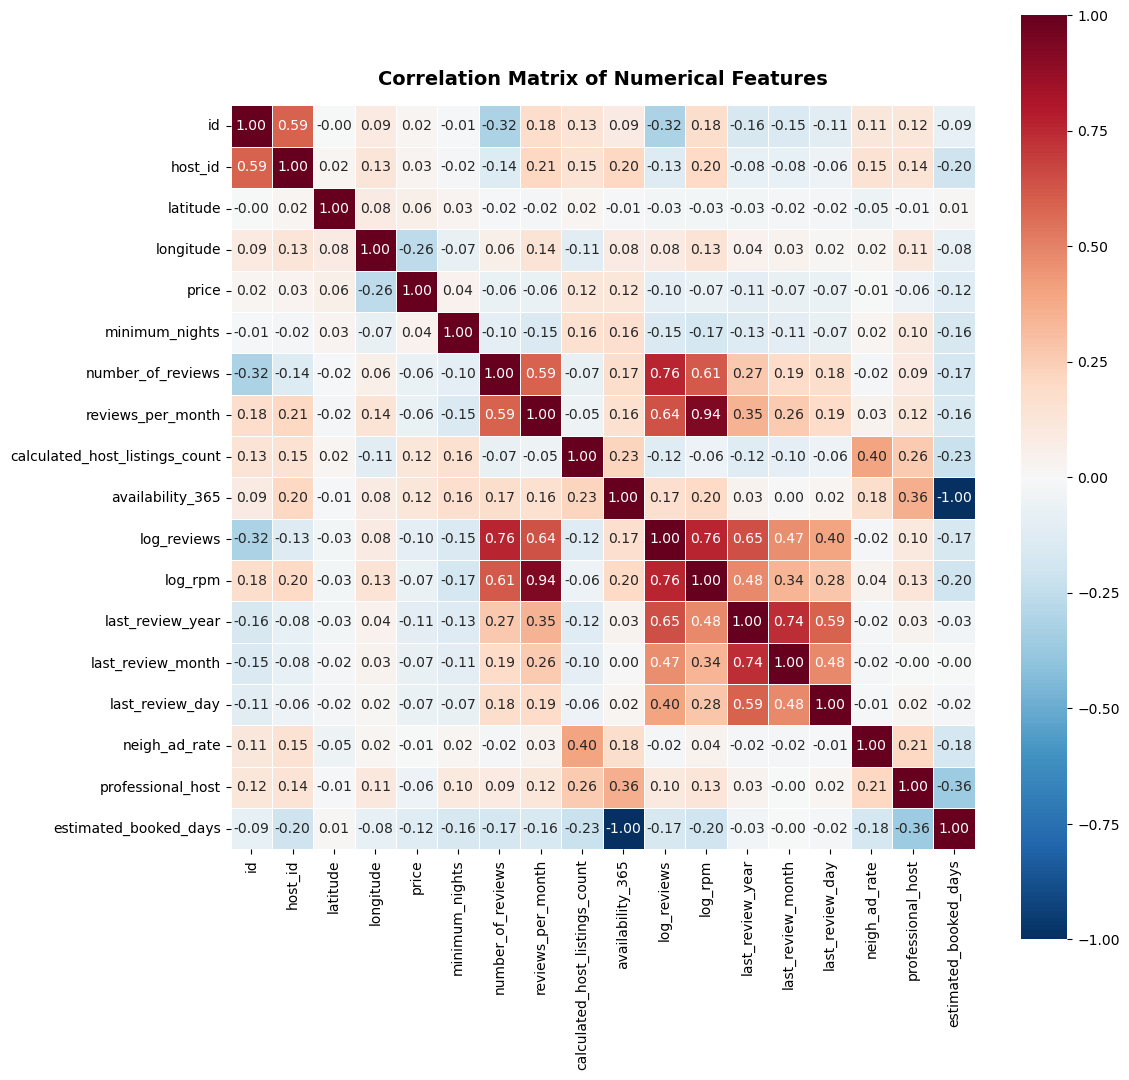

In [21]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12, 12))
sns.heatmap(corr, cmap="RdBu_r", vmax=1, vmin=-1, center=0, square=True, linewidths=.5, annot=True, fmt=".2f")
plt.title("Correlation Matrix of Numerical Features", fontsize=14, fontweight="bold", pad=15)
plt.show()

In [22]:
drop_cols = ["id", "name", "host_id", "host_name", "last_review", "number_of_reviews", "reviews_per_month", "availability_365", "log_rpm", "last_review_month", "last_review_day"]
df = df.drop(drop_cols, axis=1)

In [23]:
df.head()

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,calculated_host_listings_count,log_reviews,last_review_year,neigh_ad_rate,professional_host,estimated_booked_days
0,Brooklyn,Kensington,40.647,-73.972,Private room,149,1,6,2.303,2018,0.006,1,0
1,Manhattan,Midtown,40.754,-73.984,Entire home/apt,225,1,2,3.829,2019,0.001,1,10
2,Manhattan,Harlem,40.809,-73.942,Private room,150,3,1,0.000,0,0.000,0,0
3,Brooklyn,Clinton Hill,40.685,-73.960,Entire home/apt,89,1,1,5.602,2019,0.002,0,171
4,Manhattan,East Harlem,40.799,-73.944,Entire home/apt,80,10,1,2.303,2018,0.001,0,365


In [24]:
df.isnull().sum()

neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
calculated_host_listings_count    0
log_reviews                       0
last_review_year                  0
neigh_ad_rate                     0
professional_host                 0
estimated_booked_days             0
dtype: int64

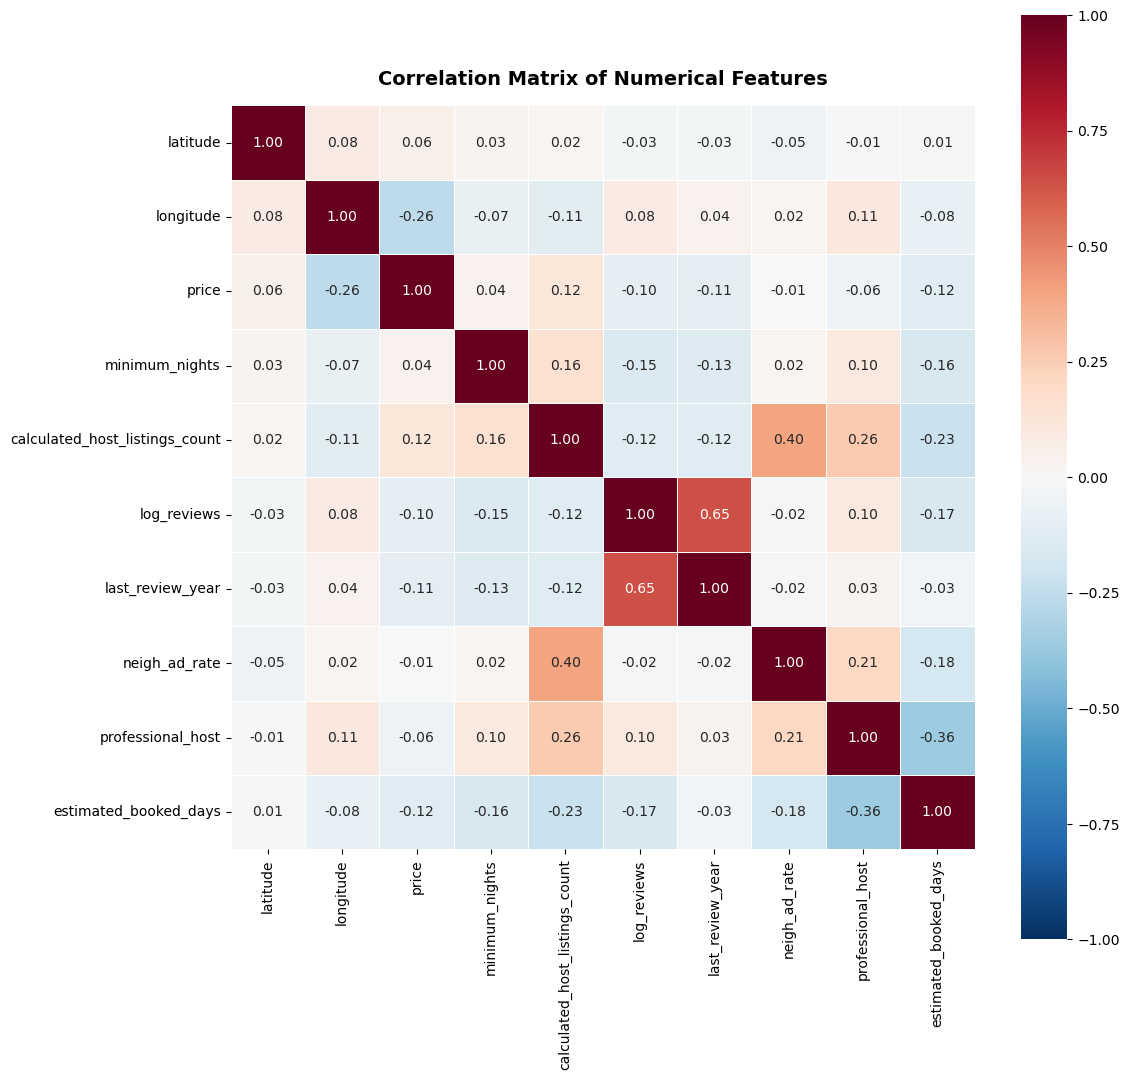

In [25]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12, 12))
sns.heatmap(corr, cmap="RdBu_r", vmax=1, vmin=-1, center=0, square=True, linewidths=.5, annot=True, fmt=".2f")
plt.title("Correlation Matrix of Numerical Features", fontsize=14, fontweight="bold", pad=15)
plt.show()